In [1]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../FRB_cosmo/FRB_cosmo/interpolation')

## Import packages
from config import *
from support import *
from cosmo_support import *

import pickle
import os
from datetime import datetime

import emcee
from multiprocess import Pool, cpu_count

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
ITP_PATH = '../FRB_cosmo/interpolation/095_C0mean.npz'
interpolations = np.load(f'../Realistic_sources/quantile_linear_interpolations.npz')
sim_error_interpolations = np.load(f'../Realistic_sources/quantile_linear_interpolations.npz')

N_EVENTS = 50
REDSHIFT_METHOD = 'rates'  # choose from 'rates', 'uniform', 'gaussian', 'lognormal' and 'powerlaw'

Z_min = 0.2
Z_max = 2.0

########################################
### Load standard parameters for pdf ###
########################################

S=0.133
S_LN=0.06
EXP_MU=182.937
SIGMA_HOST=0.605
HOF=2.813

In [3]:
# checkpoint
RESUME = False
CKP_INTERVAL = 50
DATA_FILE = './checkpoint/data_2.pkl'
MCMC_FILE = './checkpoint/mcmc_dm_diff_test.pkl'

# initial parameters
Hubble0 = 68
Omega0 = 0.3
w0 = -1.0

# MCMC parameters
N_WALKERS = 16
HEATING = 1
N_STEPS = 500

In [4]:
if os.path.exists(DATA_FILE):
    # Load previously saved data
    print(f"Loading data from {DATA_FILE}...")
    with open(DATA_FILE, 'rb') as f:
        saved_data = pickle.load(f)
    
    # events redshifts
    z_centre = saved_data['z_centre']
    # DL data
    dL_obs_centre = saved_data['dL_obs_centre']
    sigma_dL = saved_data['sigma_dL']
    # DM_diff data
    DM_diff_obs = saved_data['DM_diff_obs']
    sigma_DM_diff = saved_data['sigma_DM_diff']
    
    # Theoratical values (DM is the DM_diff)
    dL_centre = saved_data['dL_centre']
    DM_centre = saved_data['DM_centre']
    
    S = saved_data['S']
    Z_min = saved_data['Z_min']
    Z_max = saved_data['Z_max']
    REDSHIFT_METHOD = saved_data['REDSHIFT_METHOD']
    
    print(f"Successfully loaded {len(z_centre)} events from saved data.")
    
else:
    print(f"No data file {DATA_FILE}, please check path or generate data.")
    sys.exit()

if not RESUME and os.path.exists(MCMC_FILE):
    print(f"RESUME=False: Removing old save MCMC checkpoint {MCMC_FILE}...")
    os.remove(MCMC_FILE)

Loading data from ./checkpoint/data_2.pkl...
Successfully loaded 50 events from saved data.


In [5]:
def _load_and_create_interpolators():
    load_arrays = np.load(ITP_PATH)
    Sigmas = load_arrays['a']
    Errors = load_arrays['d']
    C0s = load_arrays['c'] 
    As = load_arrays['b']
    
    sigma_error_inter = interpolate.interp1d(Errors, Sigmas, kind=1, bounds_error=False,fill_value='extrapolate')
    C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1, bounds_error=False,fill_value='extrapolate')
    A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1, bounds_error=False,fill_value='extrapolate')
    
    return Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter

Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = _load_and_create_interpolators()

z_array=np.linspace(Z_min, Z_max, 1000)

def initialize_globals():
    """Initialize global variables for worker processes"""
    global sigma_error_inter, C0_sigma_inter, A_sigma_inter
    global z_array
    
    if sigma_error_inter is None:
        Sigmas, Errors, C0s, As, sigma_error_inter, C0_sigma_inter, A_sigma_inter = _load_and_create_interpolators()
        z_array = np.linspace(Z_min, Z_max, 1000)

In [6]:
def log_likelihood(theta, zs, dLs, s_dLs, DMs, s_DMs):
    """
    Calculate the log likelihood for a set of parameters given the data.

    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data

    Returns:
        Log likelihood
    """
    
    # hubble, omega, w = theta
    hubble, omega= theta
    w=-1

    log_like = 0
    
    p_event=np.zeros_like(z_array)+1.0 ############

    try:
        for idx, (z, dL_obs, s_dL, DM_obs, s_DM) in enumerate(zip(zs, dLs, s_dLs, DMs, s_DMs)):
            ####### dL kde ######
            # dL_gaussian = np.random.normal(dL_obs, s_dL, 2000)
            # dL_gaussian = np.maximum(dL_gaussian, 0)
            # GW_dL_kde = gaussian_kde(dL_gaussian)
            
            ######## p_DM(z) and p_dL(z) ########
            
            lum_distance=luminosity_distance(z=z_array, H0=hubble, Om=omega, w=w)
            p_dL = gaussian_pdf(lum_distance, dL_obs, s_dL)
            
            DM_th_array=dispersion_measure(z=z_array, H0=hubble, Om=omega, w=w, alpha=0, f_IGM_0 = 0.84)
            Delta_array = DM_obs/ DM_th_array
            
            p_DM=np.zeros_like(z_array)
            
            for idx_z, (z_val, Delta, DM_th) in enumerate(zip(z_array, Delta_array, DM_th_array)):
                error=np.sqrt(f_variance_delta(S=S, z=z_val, Om=omega, w=w))

                sigma_diff=sigma_error_inter(error)
                C0=C0_sigma_inter(sigma_diff)
                A=A_sigma_inter(sigma_diff)
                
                p_DM[idx_z]=pdf_DM_cosmo(Delta=Delta, C_0=C0, A=A, sigma=sigma_diff, alpha=3, beta=3)/DM_th
                
                """ if (np.isnan([error,C0,A,sigma_diff]).any()):
                    p_DM[idx_z]=0.0
                    # print(f'NaN found for error at z={z_val}, H0={hubble}, Om={omega}, w={w} for error={error}, C0={C0}, A={A}, sigma_diff={sigma_diff}')
                else:
                    p_DM[idx_z]=pdf_DM_cosmo(Delta=Delta, C_0=C0, A=A, sigma=sigma_diff, alpha=3, beta=3)/DM_th """
                    
            p_selection = redshift_distribution(z_array=z_array, H0=hubble, Omega_m=omega, w=w, method=REDSHIFT_METHOD)
            p_selection = normalise(p_selection, z_array)
            
            p_event = p_dL * p_DM
            integrand = p_selection * p_event
            prob = np.trapz(integrand, z_array)
            
            if prob > 1e-300:
                log_like += np.log(prob)
            else:
                print(f"Warning: prob={prob:.2e} for event {idx}, theta={theta}")
                return -np.inf
        
        return log_like
    
    except Exception as e:
        print(f"Error in log_likelihood: {e} with parameters {theta}")
        import traceback
        traceback.print_exc()
        return -np.inf


def log_prior(theta):
    """
    Calculate the log of the prior probability for a set of parameters.

    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]

    Returns:
        Log prior probability
    """
    # hubble, omega, w = theta
    hubble, omega = theta

    # Define your prior ranges here
    hubble_min, hubble_max = 40, 100 #0.016 # 0.2 # 2.0 #0.2 
    omega_min, omega_max = 0.25, 0.35 # 0.0, 1.0  
    # w_min, w_max = -2.0, 0.0 

    # Check if parameters are within prior ranges
    if (hubble_min <= hubble <= hubble_max 
        and omega_min <= omega <= omega_max
        #and w_min <= w <= w_max 
        ):
        return 0.0  # Log(1) = 0, flat prior
    else:
        return -np.inf     

def log_probability(theta, zs, dLs, s_dLs, DMs, s_DMs):
    """
    Calculate the log probability (posterior) for a set of parameters.

    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data

    Returns:
        Log posterior probability
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(theta, zs, dLs, s_dLs, DMs, s_DMs)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


### checkpoint ###

def save_checkpoint(sampler, step, state, filename="mcmc_checkpoint.pkl"):
    """
    Save MCMC checkpoint to file.
    
    Args:
        sampler: emcee sampler object
        step: Current step number
        state: Current state of the sampler
        filename: Checkpoint filename
    """
    checkpoint = {
        'step': step,
        'chain': sampler.chain,
        'log_prob': sampler.lnprobability,
        'acceptance_fraction': sampler.acceptance_fraction,
        'state_coords': state.coords if state is not None else None,
        'state_log_prob': state.log_prob if state is not None else None,
        'state_blobs': state.blobs if state is not None else None,
        'state_random_state': state.random_state if state is not None else None,
        'timestamp': datetime.now().isoformat()
    }
    
    # Save to temporary file first, then rename (atomic operation)
    temp_filename = filename + ".tmp"
    with open(temp_filename, 'wb') as f:
        pickle.dump(checkpoint, f)
    os.rename(temp_filename, filename)
    print(f"Checkpoint saved at step {step}")


def load_checkpoint(filename="DM_diff_checkpoint.pkl"):
    """
    Load MCMC checkpoint from file.
    
    Args:
        filename: Checkpoint filename
        
    Returns:
        checkpoint dict or None if file doesn't exist
    """
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            checkpoint = pickle.load(f)
        print(f"Checkpoint loaded from step {checkpoint['step']}")
        print(f"Saved at: {checkpoint['timestamp']}")
        return checkpoint
    return None


def run_mcmc_checkpoint(initial_params, zs, dLs, s_dLs, DMs, s_DMs, 
             nwalkers=32, heating=10, nsteps=2000, 
             checkpoint_interval=50, checkpoint_file=MCMC_FILE,
             resume=RESUME):
    """
    Run the MCMC analysis with checkpoint support.

    Args:
        initial_params: Initial parameter values [F, HOf, sigma_host, e_mu]
        zs, dLs, s_dLs, DMs, s_DMs: Data arrays
        nwalkers: Number of walkers
        heating: Number of heating steps
        nsteps: Number of steps per walker
        checkpoint_interval: Save checkpoint every N steps
        checkpoint_file: Checkpoint filename
        resume: If True, try to resume from checkpoint

    Returns:
        sampler: emcee sampler object with results
    """

    ndim = len(initial_params)
    
    # Try to load checkpoint if resume=True
    checkpoint = None
    if resume:
        checkpoint = load_checkpoint(checkpoint_file)
    
    # Initialize or resume
    if checkpoint is not None:
        # Resume from checkpoint
        start_step = checkpoint['step']
        
        # Recreate sampler and restore state
        with Pool(initializer=initialize_globals) as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, 
                args=(zs, dLs, s_dLs, DMs, s_DMs,), pool=pool,
                moves=[(emcee.moves.DEMove(), 0.5),
                    (emcee.moves.DESnookerMove(), 0.3),
                    (emcee.moves.StretchMove(), 0.2)]
            )
            
            # Restore chain history
            sampler._chain = checkpoint['chain']
            sampler._lnprob = checkpoint['log_prob']
            sampler._acceptance_fraction = checkpoint['acceptance_fraction']
            
            # Recreate state object
            from emcee.state import State
            state = State(
                checkpoint['state_coords'],
                log_prob=checkpoint['state_log_prob'],
                blobs=checkpoint['state_blobs'],
                random_state=checkpoint['state_random_state']
            )
            
            remaining_steps = nsteps - start_step
            
            if remaining_steps <= 0:
                print("MCMC already completed!")
                c_data = checkpoint['chain']
                lp_data = checkpoint['log_prob']
                
                sampler.backend.chain = c_data
                sampler.backend.log_prob = lp_data
                sampler.backend.iteration = nsteps
                
                sampler.backend.accepted = (checkpoint['acceptance_fraction'] * nsteps).astype(int)
                
                return sampler
                
            print(f"Resuming from step {start_step}, {remaining_steps} steps remaining")
            
            # Continue main running
            print("Continuing main running...")
            with tqdm(initial=start_step, total=nsteps) as pbar:
                for i, result in enumerate(sampler.sample(state.coords, 
                                                         iterations=remaining_steps,
                                                         store=True)):
                    current_step = start_step + i + 1
                    pbar.update(1)
                    state = result
                    
                    # Save checkpoint
                    if current_step % checkpoint_interval == 0:
                        save_checkpoint(sampler, current_step, state, checkpoint_file)
                    
                    # Check acceptance fraction
                    if i % 100 == 0:
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
                        
                        if i > 500 and acc_frac < 0.001:
                            print("Warning: acceptance fraction too low")
    
    else:
        # Start from beginning
        print("Starting new MCMC run...")
        
        # Set initial positions with small random offsets
        pos = initial_params + 0.1 * np.random.randn(nwalkers, ndim)
        
        for i in range(nwalkers):
            while log_prior(pos[i]) == -np.inf:
                pos[i] = initial_params + 0.01 * np.random.randn(ndim)
        
        with Pool(initializer=initialize_globals) as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, 
                args=(zs, dLs, s_dLs, DMs, s_DMs,), pool=pool,
                moves=[(emcee.moves.DEMove(), 0.5),
                    (emcee.moves.DESnookerMove(), 0.3),
                    (emcee.moves.StretchMove(), 0.2)]
            )
            
            # Heating phase
            print("Heating...")
            state = None
            with tqdm(total=heating) as pbar:
                for i, result in enumerate(sampler.sample(pos, iterations=heating)):
                    pbar.update(1)
                    state = result
                    if i % 100 == 0:
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
            
            # Reset sampler after heating
            sampler.reset()
            
            # Main running phase
            print("Main running...")
            with tqdm(total=nsteps) as pbar:
                for i, result in enumerate(sampler.sample(state.coords, 
                                                         iterations=nsteps,
                                                         store=True)):
                    pbar.update(1)
                    state = result
                    current_step = i + 1
                    
                    # Save checkpoint
                    if resume:
                        if current_step % checkpoint_interval == 0:
                            save_checkpoint(sampler, current_step, state, checkpoint_file)
                    
                    # Check acceptance fraction
                    if i % 100 == 0:
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
                        
                        if i > 500 and acc_frac < 0.001:
                            print("Warning: acceptance fraction too low")
    
    # Final save
    if resume:
        save_checkpoint(sampler, nsteps, state, checkpoint_file)
    
    # Check final acceptance fraction
    final_acc_frac = np.mean(sampler.acceptance_fraction)
    print(f"Final acceptance fraction: {final_acc_frac:.3f}")
    
    if final_acc_frac < 0.01:
        print("Warning: acceptance fraction too low")
    
    return sampler


##################################################################################
### Analyse results
###


'''
Because running MCMC depend on proior and likelihood function defination, so only include analyze function here.
'''

def mcmc_analyze_results(sampler, thin=15, target_prob=0.6827):
    """
    Analyze the MCMC results.
    
    Args:
        sampler: emcee sampler with results
        burn_in: Number of initial steps to discard
        thin: Thinning factor for samples
    
    Returns:
        samples: Flattened, burned-in, and thinned samples
        params_median: Median parameter values
        params_errors: Parameter uncertainties (16th and 84th percentiles)
    """
    # Discard burn-in, flatten and thin the samples
    flat_samples = sampler.get_chain(thin=thin, flat=True)
    
    # Calculate the median and 16th and 84th percentiles for the parameters
    params_median = np.median(flat_samples, axis=0)
    params_lower = np.percentile(flat_samples, 50-target_prob*50, axis=0) # np.percentile(flat_samples, 16, axis=0)
    params_upper = np.percentile(flat_samples, 50+target_prob*50, axis=0) #np.percentile(flat_samples, 84, axis=0)
    
    # Calculate errors
    params_errors = [(params_upper[i] - params_lower[i]) / 2 for i in range(len(params_median))]
    
    return flat_samples, params_median, params_errors

def mcmc_plot_results(samples, param_names, savetitle=None, bins=30, target_prob=0.6827):
    """
    Plot the MCMC results.
    
    Args:
        samples: MCMC samples
        param_names: Names of the parameters
    """
    
    # Create corner plot
    
    fig = corner.corner(
        samples, 
        labels=param_names,
        quantiles=[0.5-target_prob/2, 0.5, 0.5+target_prob/2], # [0.16, 0.5, 0.84],
        show_titles=True,
        title_kwargs={"fontsize": 12},
        title_fmt='.3f',
        bins=bins,
        smooth=True,
        color='tab:blue'
    )
    
    if savetitle is not None:
        plt.savefig(savetitle+"_corner_plot.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Plot chains for each parameter
    fig, axes = plt.subplots(len(param_names), 1, figsize=(10, 2*len(param_names)), sharex=True)
    
    for i, (ax, name) in enumerate(zip(axes, param_names)):
        ax.plot(samples[:, i], 'k-', alpha=0.3)
        ax.set_ylabel(name)
        if i == (len(param_names)-1):
            ax.set_xlabel("Sample Number")
    
    plt.tight_layout()
    if savetitle is not None:
        Path(savetitle).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(savetitle+"_chains.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

Starting new MCMC run...
Heating...


Acceptance fraction: 0.938: 100%|██████████| 1/1 [00:50<00:00, 50.39s/it]


Main running...


Acceptance fraction: 0.410: 100%|██████████| 500/500 [3:02:17<00:00, 21.87s/it]  


Final acceptance fraction: 0.406
MCMC Results:
$ H_0$  = 68.098 ± 1.308
$ \Omega_m$  = 0.318 ± 0.027


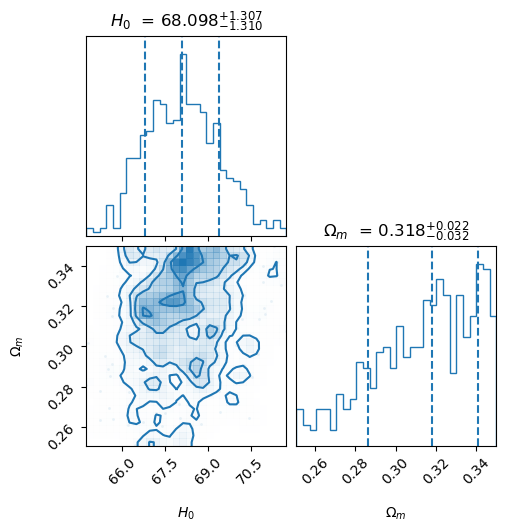

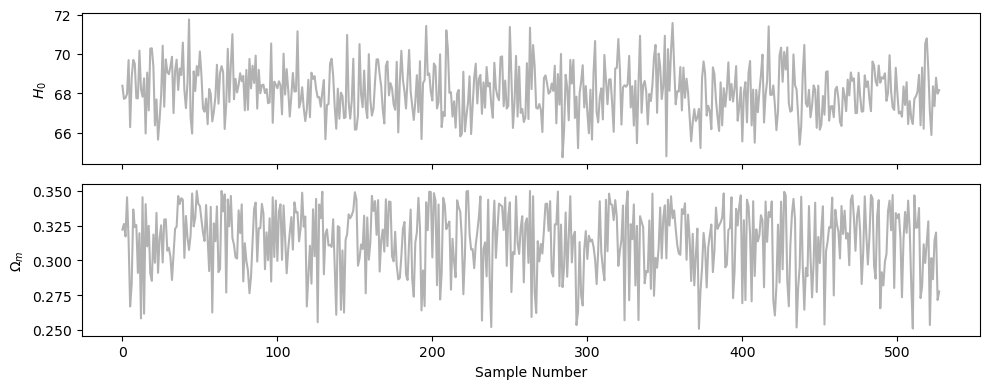

In [7]:
if __name__ == '__main__':
    # initial_params = np.array([Hubble0, Omega0, w0])
    initial_params = np.array([Hubble0, Omega0])

    # Run MCMC
    sampler = run_mcmc_checkpoint(initial_params, 
                   zs=z_centre, dLs=dL_obs_centre, s_dLs=sigma_dL, DMs=DM_diff_obs, s_DMs=sigma_DM_diff, 
                   nwalkers=N_WALKERS, heating=HEATING, nsteps=N_STEPS,
                   checkpoint_interval=CKP_INTERVAL, checkpoint_file=MCMC_FILE,resume=RESUME)
    
    # Analyze results
    samples, params_median, params_errors = mcmc_analyze_results(sampler)

    # Print results
    # param_names = [r'$ H_0$ ', r'$ \Omega_m$ ', r'$ w$ ']
    param_names = [r'$ H_0$ ', r'$ \Omega_m$ ']
    print("MCMC Results:")
    for i, name in enumerate(param_names):
        print(f"{name} = {params_median[i]:.3f} ± {params_errors[i]:.3f}")

    mcmc_plot_results(samples, param_names)